In [33]:
# This next example uses `gensim`
# You can install gensim by uncommenting the final line here, and running the cell
# This assumes that you have `conda` installed
# Note that the `yes` part of this command automatically accepts the question(s) asked in the installation
# If you'd like to review these yourself, run the command `conda install gensim` or `pip install gensim` at the command line

# !yes|conda install gensim

In [9]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-100")

embedding = model["cat"]

print(embedding.shape)

[==================================================] 100.0% 128.1/128.1MB downloaded
(100,)


In [10]:
model["king"]

array([-0.32307 , -0.87616 ,  0.21977 ,  0.25268 ,  0.22976 ,  0.7388  ,
       -0.37954 , -0.35307 , -0.84369 , -1.1113  , -0.30266 ,  0.33178 ,
       -0.25113 ,  0.30448 , -0.077491, -0.89815 ,  0.092496, -1.1407  ,
       -0.58324 ,  0.66869 , -0.23122 , -0.95855 ,  0.28262 , -0.078848,
        0.75315 ,  0.26584 ,  0.3422  , -0.33949 ,  0.95608 ,  0.065641,
        0.45747 ,  0.39835 ,  0.57965 ,  0.39267 , -0.21851 ,  0.58795 ,
       -0.55999 ,  0.63368 , -0.043983, -0.68731 , -0.37841 ,  0.38026 ,
        0.61641 , -0.88269 , -0.12346 , -0.37928 , -0.38318 ,  0.23868 ,
        0.6685  , -0.43321 , -0.11065 ,  0.081723,  1.1569  ,  0.78958 ,
       -0.21223 , -2.3211  , -0.67806 ,  0.44561 ,  0.65707 ,  0.1045  ,
        0.46217 ,  0.19912 ,  0.25802 ,  0.057194,  0.53443 , -0.43133 ,
       -0.34311 ,  0.59789 , -0.58417 ,  0.068995,  0.23944 , -0.85181 ,
        0.30379 , -0.34177 , -0.25746 , -0.031101, -0.16285 ,  0.45169 ,
       -0.91627 ,  0.64521 ,  0.73281 , -0.22752 , 

In [11]:
model.most_similar("king")

[('prince', 0.7682329416275024),
 ('queen', 0.7507691383361816),
 ('son', 0.7020888328552246),
 ('brother', 0.6985775828361511),
 ('monarch', 0.6977890133857727),
 ('throne', 0.6919989585876465),
 ('kingdom', 0.6811409592628479),
 ('father', 0.680202841758728),
 ('emperor', 0.6712858080863953),
 ('ii', 0.6676074862480164)]

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

v1 = model["king"].reshape(1, -1)
v2 = model["queen"].reshape(1, -1)

similarity = cosine_similarity(v1, v2)[0, 0]

print(similarity)

0.750769


In [37]:
model.most_similar(model["paris"]-model["france"]+model["germany"])

[('berlin', 0.8810449838638306),
 ('frankfurt', 0.795839786529541),
 ('vienna', 0.7604520916938782),
 ('munich', 0.750868022441864),
 ('germany', 0.7424821257591248),
 ('hamburg', 0.7172763347625732),
 ('paris', 0.7057967782020569),
 ('bonn', 0.6864470839500427),
 ('prague', 0.6805914044380188),
 ('cologne', 0.6736197471618652)]

In [15]:
model["king"]-model["man"]+model["woman"]

array([-0.10231996, -0.81294006,  0.10211003,  0.985924  ,  0.34218282,
        1.09095   , -0.48912996, -0.05616698, -0.21029997, -1.02996   ,
       -0.86851   ,  0.36786997,  0.01960999,  0.59259   , -0.23190099,
       -1.016919  , -0.01218399, -1.17194   , -0.52329   ,  0.60645   ,
       -0.98537004, -1.001028  ,  0.48913902,  0.630072  ,  0.58224   ,
        0.15908998,  0.43685   , -1.25351   ,  0.97054   , -0.065529  ,
        0.733763  ,  0.44219002,  1.2091839 ,  0.19698   , -0.15948   ,
        0.34364003, -0.46222997,  0.33772   ,  0.14792705, -0.24959502,
       -0.77093005,  0.522717  , -0.1283    , -0.91881   , -0.01755001,
       -0.44041002, -0.52656496,  0.33734798,  0.60639   , -0.45067   ,
       -0.04158002,  0.08408299,  1.31456   ,  0.67737997, -0.24316001,
       -2.071     , -0.60648996,  0.19710997,  0.63567   ,  0.07819998,
        0.49161002,  0.08171999,  0.70855707,  0.201938  ,  0.5155501 ,
       -0.23025298, -0.40473002,  0.39212003, -0.5093    , -0.13

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

v1 = model["queen"].reshape(1, -1)
v2 = model["king"]-model["man"]+model["woman"].reshape(1, -1)

similarity = cosine_similarity(v1, v2)[0, 0]

print(similarity)

0.7834415


In [17]:
model.most_similar(model["king"]-model["man"]+model["woman"])

[('king', 0.8551837801933289),
 ('queen', 0.7834413647651672),
 ('monarch', 0.6933801770210266),
 ('throne', 0.6833109855651855),
 ('daughter', 0.6809080839157104),
 ('prince', 0.6713142991065979),
 ('princess', 0.6644083261489868),
 ('mother', 0.6579325199127197),
 ('elizabeth', 0.6563300490379333),
 ('father', 0.6392418742179871)]

In [38]:
model.most_similar(

    positive=["king", "woman"],

    negative=["man"]

)

[('queen', 0.7698540687561035),
 ('monarch', 0.6843380928039551),
 ('throne', 0.6755736470222473),
 ('daughter', 0.6594555974006653),
 ('princess', 0.6520534157752991),
 ('prince', 0.651703417301178),
 ('elizabeth', 0.6464517712593079),
 ('mother', 0.631171703338623),
 ('emperor', 0.6106470823287964),
 ('wife', 0.6098656058311462)]

In [34]:
model.most_similar(model["king"]-model["queen"]+model["woman"])

[('man', 0.79038405418396),
 ('woman', 0.7741765379905701),
 ('father', 0.7262259125709534),
 ('son', 0.7059726119041443),
 ('boy', 0.6985020041465759),
 ('another', 0.6857764720916748),
 ('person', 0.6736670732498169),
 ('who', 0.6735799908638),
 ('brother', 0.6696274280548096),
 ('mother', 0.6615833640098572)]

In [35]:
model.most_similar(model["king"]-model["man"]+model["boy"])

[('king', 0.8525660037994385),
 ('queen', 0.6612488627433777),
 ('prince', 0.6361568570137024),
 ('son', 0.6191442012786865),
 ('brother', 0.5989434123039246),
 ('uncle', 0.5902642011642456),
 ('emperor', 0.578257143497467),
 ('throne', 0.5773313641548157),
 ('father', 0.5682175159454346),
 ('boy', 0.5664733648300171)]

In [22]:
model.most_similar("university")

[('college', 0.8294211626052856),
 ('harvard', 0.8156034350395203),
 ('yale', 0.81138014793396),
 ('professor', 0.8103784918785095),
 ('graduate', 0.7993001341819763),
 ('faculty', 0.7793422937393188),
 ('princeton', 0.7627182006835938),
 ('institute', 0.7604438662528992),
 ('school', 0.7548453211784363),
 ('stanford', 0.7424824833869934)]

In [24]:
model["cat"]

array([ 0.23088  ,  0.28283  ,  0.6318   , -0.59411  , -0.58599  ,
        0.63255  ,  0.24402  , -0.14108  ,  0.060815 , -0.7898   ,
       -0.29102  ,  0.14287  ,  0.72274  ,  0.20428  ,  0.1407   ,
        0.98757  ,  0.52533  ,  0.097456 ,  0.8822   ,  0.51221  ,
        0.40204  ,  0.21169  , -0.013109 , -0.71616  ,  0.55387  ,
        1.1452   , -0.88044  , -0.50216  , -0.22814  ,  0.023885 ,
        0.1072   ,  0.083739 ,  0.55015  ,  0.58479  ,  0.75816  ,
        0.45706  , -0.28001  ,  0.25225  ,  0.68965  , -0.60972  ,
        0.19578  ,  0.044209 , -0.31136  , -0.68826  , -0.22721  ,
        0.46185  , -0.77162  ,  0.10208  ,  0.55636  ,  0.067417 ,
       -0.57207  ,  0.23735  ,  0.4717   ,  0.82765  , -0.29263  ,
       -1.3422   , -0.099277 ,  0.28139  ,  0.41604  ,  0.10583  ,
        0.62203  ,  0.89496  , -0.23446  ,  0.51349  ,  0.99379  ,
        1.1846   , -0.16364  ,  0.20653  ,  0.73854  ,  0.24059  ,
       -0.96473  ,  0.13481  , -0.0072484,  0.33016  , -0.1236

In [27]:
import pandas as pd

In [30]:
words = model.index_to_key

In [31]:
words

['the',
 ',',
 '.',
 'of',
 'to',
 'and',
 'in',
 'a',
 '"',
 "'s",
 'for',
 '-',
 'that',
 'on',
 'is',
 'was',
 'said',
 'with',
 'he',
 'as',
 'it',
 'by',
 'at',
 '(',
 ')',
 'from',
 'his',
 "''",
 '``',
 'an',
 'be',
 'has',
 'are',
 'have',
 'but',
 'were',
 'not',
 'this',
 'who',
 'they',
 'had',
 'i',
 'which',
 'will',
 'their',
 ':',
 'or',
 'its',
 'one',
 'after',
 'new',
 'been',
 'also',
 'we',
 'would',
 'two',
 'more',
 "'",
 'first',
 'about',
 'up',
 'when',
 'year',
 'there',
 'all',
 '--',
 'out',
 'she',
 'other',
 'people',
 "n't",
 'her',
 'percent',
 'than',
 'over',
 'into',
 'last',
 'some',
 'government',
 'time',
 '$',
 'you',
 'years',
 'if',
 'no',
 'world',
 'can',
 'three',
 'do',
 ';',
 'president',
 'only',
 'state',
 'million',
 'could',
 'us',
 'most',
 '_',
 'against',
 'u.s.',
 'so',
 'them',
 'what',
 'him',
 'united',
 'during',
 'before',
 'may',
 'since',
 'many',
 'while',
 'where',
 'states',
 'because',
 'now',
 'city',
 'made',
 'like',
 

In [32]:
len(words)

400000

In [39]:
?model.most_similar

Signature:
model.most_similar(
    positive=None,
    negative=None,
    topn=10,
    clip_start=0,
    clip_end=None,
    restrict_vocab=None,
    indexer=None,
)
Docstring:
Find the top-N most similar keys.
Positive keys contribute positively towards the similarity, negative keys negatively.

This method computes cosine similarity between a simple mean of the projection
weight vectors of the given keys and the vectors for each key in the model.
The method corresponds to the `word-analogy` and `distance` scripts in the original
word2vec implementation.

Parameters
----------
positive : list of (str or int or ndarray) or list of ((str,float) or (int,float) or (ndarray,float)), optional
    List of keys that contribute positively. If tuple, second element specifies the weight (default `1.0`)
negative : list of (str or int or ndarray) or list of ((str,float) or (int,float) or (ndarray,float)), optional
    List of keys that contribute negatively. If tuple, second element specifies the we

In [40]:
model.most_similar(model["sushi"]-model["japan"]+model["germany"])

[('pastry', 0.5279678702354431),
 ('sushi', 0.5256780982017517),
 ('ducasse', 0.5234885215759277),
 ('gourmet', 0.5166001915931702),
 ('hamburger', 0.5080069303512573),
 ('sausage', 0.5010420680046082),
 ('dessert', 0.49995914101600647),
 ('cheese', 0.4974646270275116),
 ('fries', 0.47950708866119385),
 ('cheesecake', 0.4774067997932434)]

In [42]:
model.most_similar(model["bratwurst"])

[('bratwurst', 1.0),
 ('sauerkraut', 0.6685113310813904),
 ('sausages', 0.6250906586647034),
 ('kielbasa', 0.6003971695899963),
 ('sausage', 0.5902236700057983),
 ('choucroute', 0.5236543416976929),
 ('oktoberfest', 0.5162938833236694),
 ('frankfurters', 0.5039278864860535),
 ('currywurst', 0.4967309236526489),
 ('merguez', 0.49567630887031555)]

In [43]:
model.most_similar("bratwurst")

[('sauerkraut', 0.6685113310813904),
 ('sausages', 0.6250906586647034),
 ('kielbasa', 0.6003971695899963),
 ('sausage', 0.5902236700057983),
 ('choucroute', 0.5236543416976929),
 ('oktoberfest', 0.5162938833236694),
 ('frankfurters', 0.5039278864860535),
 ('currywurst', 0.4967309534549713),
 ('merguez', 0.49567630887031555),
 ('ravioli', 0.49563753604888916)]

In [45]:
model.most_similar(positive="hot")

[('cool', 0.771088719367981),
 ('cold', 0.7251607775688171),
 ('warm', 0.6978106498718262),
 ('heat', 0.6798572540283203),
 ('soft', 0.6601648926734924),
 ('dry', 0.656905472278595),
 ('hottest', 0.6359643340110779),
 ('ice', 0.6257197856903076),
 ('mix', 0.6253519058227539),
 ('summer', 0.6186624765396118)]

In [46]:
model.most_similar(positive="desert", negative="hot")

[('mojave', 0.5249858498573303),
 ('sonoran', 0.506641685962677),
 ('cholistan', 0.5048995614051819),
 ('namib', 0.5004015564918518),
 ('chihuahuan', 0.49228018522262573),
 ('anza-borrego', 0.4881615936756134),
 ('negev', 0.47294533252716064),
 ('judean', 0.4635242819786072),
 ('taklamakan', 0.4539128541946411),
 ('tabernas', 0.4524003267288208)]

In [50]:
model.most_similar(positive=["edinburgh","university"])

[('cambridge', 0.7644388675689697),
 ('oxford', 0.7513911128044128),
 ('glasgow', 0.7460185885429382),
 ('college', 0.7333678007125854),
 ('academy', 0.6862157583236694),
 ('harvard', 0.682809591293335),
 ('professor', 0.6792548298835754),
 ('yale', 0.6773259043693542),
 ('melbourne', 0.6729219555854797),
 ('princeton', 0.6684866547584534)]

In [51]:
model.most_similar("haggis")

[('moresco', 0.5662769079208374),
 ('greengrass', 0.5598293542861938),
 ('verhoeven', 0.5274224281311035),
 ('oakenfold', 0.5029656291007996),
 ('chayefsky', 0.49769753217697144),
 ('gaghan', 0.49258142709732056),
 ('reubens', 0.4887356162071228),
 ('resnais', 0.4843463599681854),
 ('darabont', 0.48265331983566284),
 ('w.s.', 0.46595197916030884)]

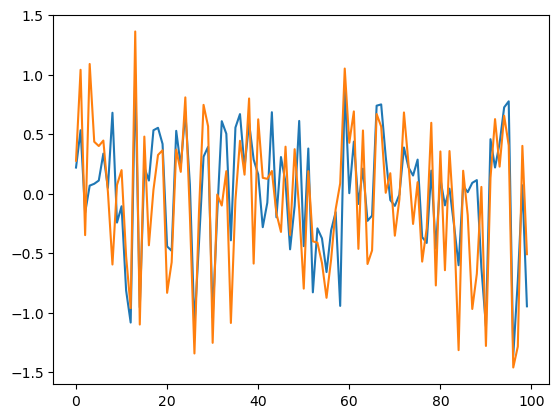

In [55]:
import matplotlib.pyplot as plt 
plt.plot(model["viola"])
plt.plot(model["violin"])

In [56]:
corr = np.corrcoef(model["viola"],model["violin"])

In [57]:
corr

array([[1.        , 0.74880676],
       [0.74880676, 1.        ]])

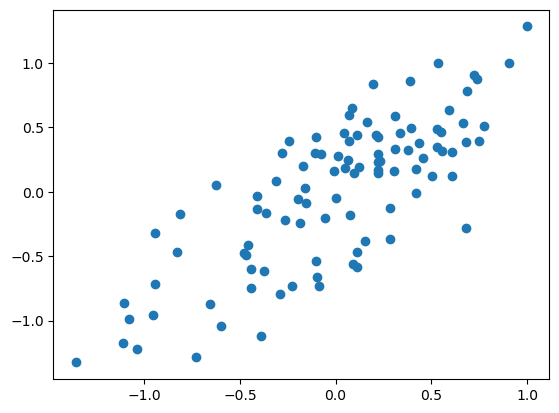

In [ ]:
plt.

In [ ]:
import pandas as pd
import seaborn as sns

sns.pairplot(pd.DataFrame([model["violin"], model["viola"], model["cello"]]))

KeyboardInterrupt: 